In [1]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import math
from scipy.spatial.distance import cdist

In [2]:
# Select candidates 

person1 = 'Martins'
person2 = 'Gouveia_Melo'

In [3]:
# Load visual pkl for debate with person 1 and person 2 OR all debates with person 1 OR all debates
pklfiles = []

if not person1:
    for file in os.listdir('Project_Features'):
        if file.endswith('visual.pkl'):
            pklfiles.append(file)
elif not person2:
    for file in os.listdir('Project_Features'):
        if file.endswith('visual.pkl') and person1 in file:
            pklfiles.append(file)
else:
    for file in os.listdir('Project_Features'):
        if file.endswith('visual.pkl') and person1 in file and person2 in file:
            pklfiles.append(file)


data = []

for video in pklfiles:
    print(f"Loading: {video}")
    df = pd.read_pickle(os.path.join('Project_Features', video))
    data.append(df)

data = pd.concat(data, ignore_index=True)

data['Video_Name'] = data['Frame'].str.extract(r'Frames/([^/]+)/')
data['Frame_Number'] = data['Frame'].str.extract(r'frame_(\d+)\.jpg').astype(int)
data = data.sort_values(by=['Video_Name', 'Frame_Number']).reset_index(drop=True)


Loading: Martins_vs_Gouveia_Melo_November_23_visual.pkl


In [4]:
master_data = []

for index, row in data.iterrows():
    frame_id = row['Frame']
    frame_number = row['Frame_Number']
    faces = row['Fer']
    poses = row['Poses'] # This contains the body bbox and the 17 keypoints
    
    if isinstance(faces, list) and len(faces) > 0 and len(faces)<=3:
        valid_faces = [f for f in faces if isinstance(f, dict) and 'bbox' in f]
        people_count = len(valid_faces)
        
        for i, face in enumerate(valid_faces):
            # 1. Face Coordinates
            f_box = face['bbox'] # [x1, y1, x2, y2]
            f_width = f_box[2] - f_box[0]
            f_height = f_box[3] - f_box[1]
            
            f_x_center = f_box[0] + (f_width / 2)
            f_y_center = f_box[1] + (f_height / 2) # Get Y center too!
            face_area = f_width * f_height
            
            top_emotion = face.get('top_emotion')
            probability = face['probabilities'].get(top_emotion) if top_emotion and 'probabilities' in face else None
            landmarks = face.get('landmarks')
            
            # 2. MATCH THE BODY TO THE FACE
            matched_body_bbox = None
            matched_pose_keypoints = None
            
            if isinstance(poses, list):
                for person_body in poses:
                    if isinstance(person_body, dict)and len(person_body) > 0:
                        b_box = person_body['bbox'] 
                        
                        # is the center of the face inside this body's bounding box?
                        #note that b_box[3] > bbox[1] because y axis goes down
                        if (b_box[0] <= f_x_center <= b_box[2]) and (b_box[1] <= f_y_center <= b_box[3]):
                            matched_body_bbox = b_box
                            matched_pose_keypoints = person_body.get('pose') # The 17x3 matrix
                            break 
            
            # 3. Append everything safely
            master_data.append({
                'Frame': frame_id,
                'Frame_Number': frame_number,
                'People_Count': people_count,
                'Person_Index': i,
                'Face_X_Center': f_x_center,
                'Face_Area': face_area,
                'Face_BBox': f_box,
                'Body_BBox': matched_body_bbox,         
                'Top_Emotion': top_emotion,
                'Emotion_Prob': probability,
                'Landmarks': landmarks,
                'Pose_Keypoints': matched_pose_keypoints 
            })
            
    else:
        # Handle empty frames
        master_data.append({
            'Frame': frame_id, 'Frame_Number': frame_number, 'People_Count': 0, 'Person_Index': None,
            'Face_X_Center': None, 'Face_Area': None, 'Face_BBox': None,
            'Body_BBox': None, 'Top_Emotion': None, 'Emotion_Prob': None,
            'Landmarks': None, 'Pose_Keypoints': None
        })

df_people = pd.DataFrame(master_data)
print(f"Important data (df shape): {df_people.shape}")

Important data (df shape): (3261, 12)


Screen time by number of people detected:
  0 people: 2 frames (0min 2s)
  1 people: 989 frames (16min 29s)
  2 people: 901 frames (15min 1s)
  3 people: 156 frames (2min 36s)


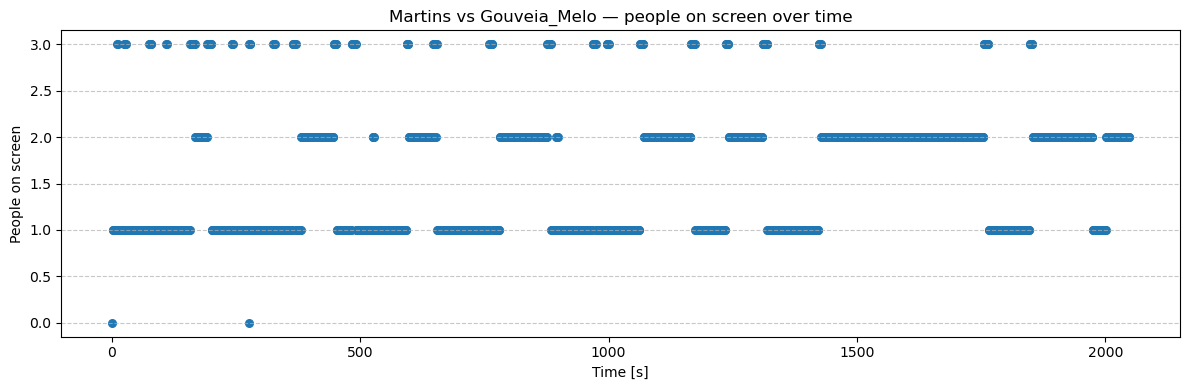

In [5]:
#because our data frame is separated into one person (instead of 1 frame=1row)
#we have to group the rows that correspond to the same frame to plot the timeline

grouped_rows = df_people.groupby('Frame_Number')
people_in_frame= grouped_rows['People_Count'].max() #in case i have the same frame detecting 1 or 2 faces --> keep2 
df_frames = people_in_frame.reset_index()

# 
counts = df_frames['People_Count'].value_counts().sort_index()
print("Screen time by number of people detected:")
for n_people, n_frames in counts.items():
    minuts = n_frames//60
    secs = n_frames%60
    print(f"  {n_people} people: {n_frames} frames ({minuts}min {secs}s)")


plt.figure(figsize=(12, 4))
plt.scatter(df_frames['Frame_Number'], df_frames['People_Count'], marker='o', s=30)
plt.xlabel('Time [s]')
plt.ylabel('People on screen')
plt.title(f'{person1} vs {person2} — people on screen over time')
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


## DINIS CODE 

In [6]:

audio_files = sorted([f for f in os.listdir('Project_Features') if f.endswith('_audio.pkl')])

dfs = []
for f in audio_files:
    df = pd.read_pickle(os.path.join('Project_Features', f))
    df['video'] = f.replace('_audio.pkl', '')
    dfs.append(df)

data_audio = pd.concat(dfs, ignore_index=True)
print(f'Loaded {len(data_audio)} segments across {data_audio["video"].nunique()} videos')

Loaded 2656 segments across 28 videos


In [7]:
def parse_embedding(s):
    if isinstance(s, np.ndarray):
        return s
    return np.fromstring(s.strip('[]'), sep=' ')

data_audio['speak_embeddings'] = data_audio['speak_embeddings'].apply(parse_embedding)

data_parties       = pd.read_pickle(os.path.join('Project_Features', 'candidate_party.pkl'))
candidate_to_party = dict(zip(data_parties['Candidate'], data_parties['Party']))

CANDIDATES = [
    'Cotrim_Figueiredo', 'Filipe', 'Gouveia_Melo',
    'Marques_Mendes', 'Martins', 'Pinto', 'Seguro', 'Ventura'
]
debate_videos = sorted([v for v in data_audio['video'].unique() if 'vs' in v])

def extract_candidates(video_name):
    for c in CANDIDATES:
        if video_name.startswith(c):
            rest = video_name[len(c) + len('_vs_'):]
            for c2 in CANDIDATES:
                if rest.startswith(c2):
                    return c, c2
    return None, None

In [13]:
debate_centroids = {}
cluster_col      = np.full(len(data_audio), -1, dtype=int)

for video_name in debate_videos:
    mask = data_audio['video'] == video_name
    idx  = data_audio.index[mask]
    E    = np.stack(data_audio.loc[idx, 'speak_embeddings'].values)
    km   = KMeans(n_clusters=3, random_state=42, n_init=10)
    lbls = km.fit_predict(E)
    cluster_col[idx]              = lbls
    debate_centroids[video_name]  = km.cluster_centers_

data_audio['cluster_k3'] = cluster_col
print(f'k=3 clustering done for {len(debate_centroids)} debates')

k=3 clustering done for 28 debates


In [9]:

def candidate_centroid_per_debate(candidate, debate_centroids):
    their_debates = [v for v in debate_centroids if candidate in v]
    if len(their_debates) < 2:
        return {}
    best = {}
    for video in their_debates:
        others = [v for v in their_debates if v != video]
        cents  = debate_centroids[video]
        scores = [
            sum(cdist(cents[i].reshape(1,-1), debate_centroids[ov], metric='cosine')[0].min()
                for ov in others)
            for i in range(3)
        ]
        best[video] = cents[int(np.argmin(scores))]
    return best

global_centroids = {}
for cand in CANDIDATES:
    result = candidate_centroid_per_debate(cand, debate_centroids)
    if result:
        global_centroids[cand] = np.mean(np.stack(list(result.values())), axis=0)

print(f'Global centroids built for {len(global_centroids)} candidates')

# --- assign speaker labels ---
speaker_col = np.full(len(data_audio), 'unknown', dtype=object)

for video_name in debate_videos:
    cA, cB = extract_candidates(video_name)
    if cA is None:
        continue
    mask  = data_audio['video'] == video_name
    idx   = data_audio.index[mask]
    cents = debate_centroids[video_name]

    dist_A = cdist(cents, global_centroids[cA].reshape(1,-1), metric='cosine').flatten()
    dist_B = cdist(cents, global_centroids[cB].reshape(1,-1), metric='cosine').flatten()

    cluster_map = {}
    available   = {0, 1, 2}
    best_A = int(np.argmin([dist_A[i] if i in available else np.inf for i in range(3)]))
    cluster_map[best_A] = cA
    available.remove(best_A)
    best_B = int(np.argmin([dist_B[i] if i in available else np.inf for i in range(3)]))
    cluster_map[best_B] = cB
    available.remove(best_B)
    cluster_map[available.pop()] = 'host'

    labels = data_audio.loc[idx, 'cluster_k3'].values
    speaker_col[idx] = [cluster_map[l] for l in labels]

data_audio['speaker'] = speaker_col
data_audio['party']   = data_audio['speaker'].map(candidate_to_party).fillna('host')
print('Speaker assignment done.')

Global centroids built for 8 candidates
Speaker assignment done.


In [10]:

DEBATE = 'Martins_vs_Gouveia_Melo_November_23'  # change to match your file name exactly

debate_audio = (
    data_audio[data_audio['video'] == DEBATE]
    .copy()
    .sort_values('time stamp')
    .reset_index(drop=True)
)

debate_audio['frame_start'] = (debate_audio['time stamp'].apply(math.floor) + 1).astype(int)
debate_audio['frame_end']   = (debate_audio['time stamp'] + debate_audio['duration']).apply(math.ceil).astype(int)
debate_audio['frames']      = debate_audio.apply(
    lambda r: list(range(r['frame_start'], r['frame_end'] + 1)), axis=1
)

print(f'Audio segments for {DEBATE}: {len(debate_audio)}')
print(debate_audio['speaker'].value_counts())

Audio segments for Martins_vs_Gouveia_Melo_November_23: 99
speaker
Gouveia_Melo    57
Martins         26
host            16
Name: count, dtype: int64


## Screen Time

In [11]:
frame_to_speaker = {}
for _, row in debate_audio.iterrows():
    #frames coolum is a list that already has the frames numbers corresponding to the audio segment
    for f in row['frames']:
        frame_to_speaker[f] = row['speaker']

# add speaker column to df_frame (your one-row-per-frame dataframe)
df_frames['speaker'] = df_frames['Frame_Number'].map(frame_to_speaker)

# now label single-person frames
def assign_label(row):
    if row['People_Count'] == 2:
        #check if they are the two candidates or if one of them is the host
        return 'both'
    elif row['People_Count'] == 1:
        if pd.notna(row['speaker']):
            return row['speaker']
        else:
            return 'unknown'
    elif row['People_Count']==3:
        return 'all'
    else:
        return 'no_people'

df_frames['scene_label'] = df_frames.apply(assign_label, axis=1)

Screen time (seconds):
scene_label
both            901
Martins         400
Gouveia_Melo    342
all             156
unknown         141
host            106
no_people         2
Name: count, dtype: int64

--- Total Screen time ---
Martins: 24 min 17 s
Gouveia_Melo: 23 min 19 s
Host: 4 min 22 s


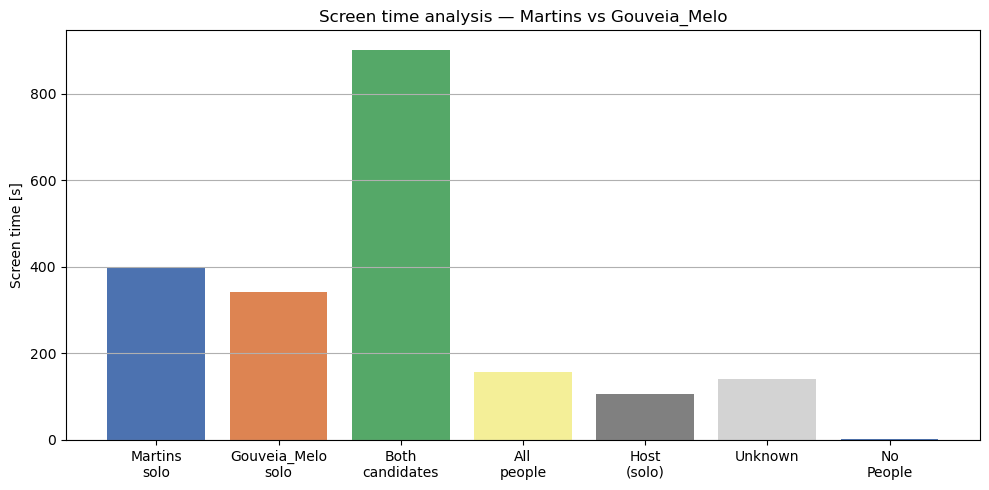

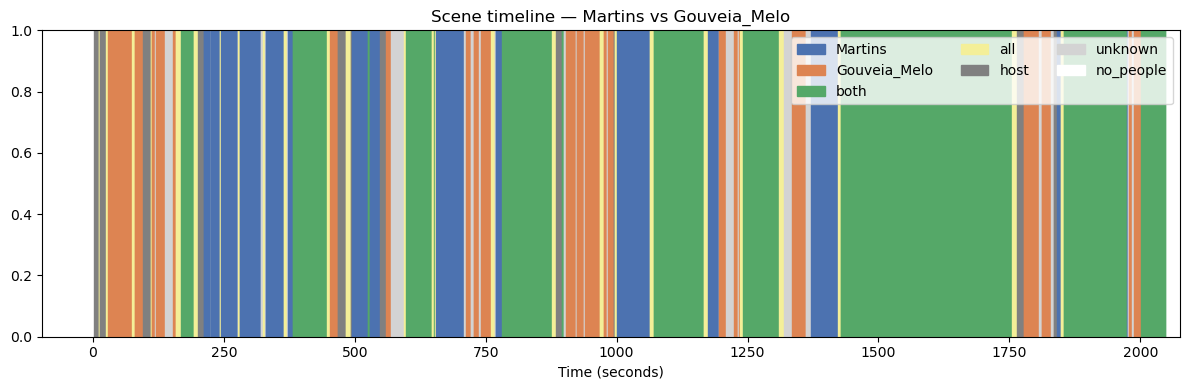

In [12]:
screen_time = df_frames['scene_label'].value_counts()
print("Screen time (seconds):")
print(screen_time)


total_frames = len(df_frames)

solo_a = (df_frames['scene_label'] == person1).sum()
solo_b = (df_frames['scene_label'] == person2).sum()
both = (df_frames['scene_label'] == 'both').sum()
all_people = (df_frames['scene_label'] == 'all').sum()
host = (df_frames['scene_label'] == 'host').sum()
unknown  = (df_frames['scene_label'] == 'unknown').sum()
no_people = (df_frames['scene_label'] == 'no_people').sum()

total_person1 = solo_a+both+all_people
total_person2 = solo_b+both+all_people
total_host = host+all_people

print(f"\n--- Total Screen time ---")
print(f"{person1}: {total_person1// 60} min {total_person1%60} s")
print(f"{person2}: {total_person2// 60} min {total_person2%60} s")
print(f"Host: {total_host// 60} min {total_host%60} s")


label_p1 = person1 + '\n'+ 'solo'
label_p2 = person2 + '\n' + 'solo'
labels = [label_p1, label_p2, 'Both\ncandidates', 'All\npeople', 'Host\n(solo)', 'Unknown', 'No\nPeople']
values = [solo_a, solo_b, both, all_people, host, unknown, no_people]
colors = ['#4C72B0', '#DD8452', '#55A868', "#F4EF98", 'gray', 'lightgray']

plt.figure(figsize=(10, 5))
plt.bar(labels, values, color=colors)
plt.ylabel('Screen time [s]')
plt.title(f'Screen time analysis — {person1} vs {person2}')
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()

color_map = {
    person1: '#4C72B0',
    person2:  '#DD8452',
    'both':    '#55A868',
    'all':     "#F4EF98",
    'host':    'gray',
    'unknown': 'lightgray',
    'no_people':   'white'
}

plt.figure(figsize=(12, 4))
for _, row in df_frames.iterrows():
    color = color_map.get(row['scene_label'], 'white')
    plt.axvline(x=row['Frame_Number'], color=color, linewidth=1)

# legend
from matplotlib.patches import Patch
legend = [Patch(color=c, label=l) for l, c in color_map.items()]
plt.legend(handles=legend, loc='upper right', ncol=3)
plt.xlabel('Time (seconds)')
plt.title(f'Scene timeline — {person1} vs {person2}')
plt.tight_layout()
plt.show()
